<a href="https://colab.research.google.com/github/deepa22-eng/Assignment-1/blob/main/Copy_of_QM9_GNN_FinalProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# CHEM 4930/5610 — Final Project
## Molecular Property Prediction with Graph Neural Networks on QM9

**Course:** Chemical Applications of Machine Learning — Spring 2026  
**Instructor:** Dr. Omar Valsson






---
## PART 0 — Setup

In [ ]:
# Install packages if running on Google Colab
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !pip install rdkit torch_geometric -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 74.3 MB/s eta 0:00:00


In [ ]:
# ─── Standard libraries ───────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math, random, os, pickle

# ─── RDKit ────────────────────────────────────────────────────────────────────
from rdkit import Chem
from rdkit.Chem import rdDepictor
from rdkit.Chem.Draw import MolToImage

# ─── PyTorch ──────────────────────────────────────────────────────────────────
import torch
import torch.nn.functional as Fun
from torch.nn import Linear, Sequential, BatchNorm1d, ReLU

# ─── PyTorch Geometric ────────────────────────────────────────────────────────
from torch_geometric.data import Data, InMemoryDataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, GINConv, global_mean_pool, global_add_pool

# ─── Sklearn (for metrics) ────────────────────────────────────────────────────
from sklearn.metrics import mean_absolute_error, r2_score

# ─── Progress bar ─────────────────────────────────────────────────────────────
from tqdm.auto import tqdm

# ─── Device ───────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("All imports OK!")
print(f"Using device: {device}")

All imports OK!
Using device: cuda


The QM9 CSV contains 19 molecular properties. We target:

Column gap — HOMO-LUMO gap (eV), index 4 among the quantum properties.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  ★  CHANGE SETTINGS HERE
# ══════════════════════════════════════════════════════════════════════════════
TARGET_PROPERTY = 'gap'       # HOMO-LUMO gap — change to any QM9 column name
MAX_MOLECULES   = None        # None = use all 134k molecules
                              # Set to e.g. 10000 for fast development runs

# Hyperparameters
EPOCHS        = 200
LEARNING_RATE = 5e-4
BATCH_SIZE    = 128
DIM_HIDDEN    = 128
RANDOM_SEED   = 42
# ══════════════════════════════════════════════════════════════════════════════

random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f"Target property : {TARGET_PROPERTY}")
print(f"Max molecules   : {MAX_MOLECULES or 'all 134,000'}")
print(f"Epochs          : {EPOCHS}")
print(f"Learning rate   : {LEARNING_RATE}")
print(f"Batch size      : {BATCH_SIZE}")
print(f"Hidden dim      : {DIM_HIDDEN}")

Target property : gap
Max molecules   : all 134,000
Epochs          : 200
Learning rate   : 0.0005
Batch size      : 128
Hidden dim      : 128


---
## PART 2 — Download and Explore the QM9 Dataset

The QM9 dataset (Ramakrishnan et al., 2014) contains **134,000 small organic molecules**
with H, C, N, O, F atoms and up to 9 heavy atoms.  
DFT (B3LYP/6-31G) was used to compute 19 electronic and thermodynamic properties.


In [ ]:
%%bash
if [ ! -f qm9.sdf ]; then
    echo "Downloading QM9 dataset..."
    wget -q https://deepchemdata.s3.us-west-1.amazonaws.com/datasets/qm9.tar.gz
    tar xzf qm9.tar.gz
    echo "Done."
else
    echo "QM9 files already present."
fi
ls -lh qm9.sdf qm9.sdf.csv

Done.
-rw-rw-r-- 1 1000 1000 241M Jul  7  2025 qm9.sdf
-rw-rw-r-- 1 1000 1000  27M Jul  7  2025 qm9.sdf.csv


In [ ]:
# Read molecules with explicit Hs (removeHs=False) because QM9 properties
# were computed with all hydrogen atoms included in the DFT calculation.
# sanitize=False avoids RDKit errors on valid but unusual QM9 structures.
molecules = Chem.SDMolSupplier('qm9.sdf', removeHs=False, sanitize=False)
data_csv  = pd.read_csv('qm9.sdf.csv')

print(f"Total molecules : {len(molecules):,}")
print(f"Property columns: {list(data_csv.columns)}")
data_csv.head(3)

Total molecules : 133,885
Property columns: ['mol_id', 'A', 'B', 'C', 'mu', 'alpha', 'homo', 'lumo', 'gap', 'r2', 'zpve', 'u0', 'u298', 'h298', 'g298', 'cv', 'u0_atom', 'u298_atom', 'h298_atom', 'g298_atom']


,mol_id,A,B,C,mu,alpha,homo,lumo,gap,r2,zpve,u0,u298,h298,g298,cv,u0_atom,u298_atom,h298_atom,g298_atom
0,gdb_1,157.71180,157.70997,157.70699,0.0000,13.21,-0.3877,0.1171,0.5048,35.3641,0.044749,-40.478930,-40.476062,-40.475117,-40.498597,6.469,-395.999595,-398.643290,-401.014647,-372.471772
1,gdb_2,293.60975,293.54111,191.39397,1.6256,9.46,-0.2570,0.0829,0.3399,26.1563,0.034358,-56.525887,-56.523026,-56.522082,-56.544961,6.316,-276.861363,-278.620271,-280.399259,-259.338802
2,gdb_3,799.58812,437.90386,282.94545,1.8511,6.31,-0.2928,0.0687,0.3615,19.0002,0.021375,-76.404702,-76.401867,-76.400922,-76.422349,6.002,-213.087624,-213.974294,-215.159658,-201.407171


[16:43:46] Both bonds on one end of an atropisomer are on the same side - atoms are: 2 1


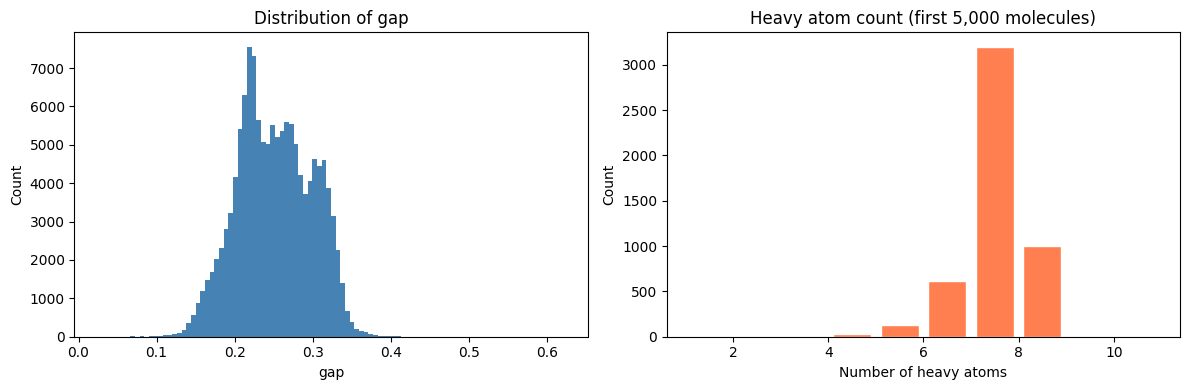

count    133885.000000
mean          0.251100
std           0.047519
min           0.024600
25%           0.216300
50%           0.249400
75%           0.288200
max           0.622100
Name: gap, dtype: float64


In [ ]:
# Explore the distribution of the target property
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(data_csv[TARGET_PROPERTY], bins=100, color='steelblue', edgecolor='none')
axes[0].set_xlabel(TARGET_PROPERTY)
axes[0].set_ylabel('Count')
axes[0].set_title(f'Distribution of {TARGET_PROPERTY}')

# Heavy-atom count distribution
heavy_counts = []
n_check = min(5000, len(molecules))
for i in range(n_check):
    mol = molecules[i]
    if mol is not None:
        heavy_counts.append(sum(1 for a in mol.GetAtoms() if a.GetAtomicNum() != 1))
axes[1].hist(heavy_counts, bins=range(1, 12), color='coral', edgecolor='white', rwidth=0.8)
axes[1].set_xlabel('Number of heavy atoms')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Heavy atom count (first {n_check:,} molecules)')

plt.tight_layout()
plt.show()

print(data_csv[TARGET_PROPERTY].describe())

Molecule 120  |  gap = 0.31690


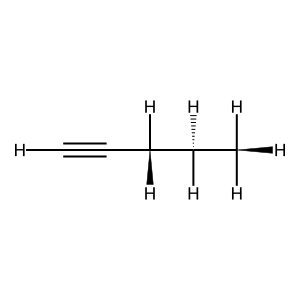

In [ ]:
# Visualise a sample molecule
def visualize_rdkit_mol_2d(mol, title=''):
    """Draw a 2D depiction of an RDKit Mol object."""
    mol_copy = Chem.Mol(mol)
    try:
        Chem.SanitizeMol(mol_copy)
        Chem.Kekulize(mol_copy)
    except Exception:
        pass
    rdDepictor.Compute2DCoords(mol_copy)
    img = MolToImage(mol_copy, size=(300, 300))
    if title:
        print(title)
    display(img)

idx = 120
visualize_rdkit_mol_2d(
    molecules[idx],
    title=f"Molecule {idx}  |  {TARGET_PROPERTY} = {data_csv[TARGET_PROPERTY].iloc[idx]:.5f}"
)

---
## PART 3 — Molecule → PyG Graph




In [ ]:
# ── Feature vocabularies ──────────────────────────────────────────────────────
# QM9 atoms: H(1), C(6), N(7), O(8), F(9) — we cover 1-8, F lands in 'unknown'
ATOM_FEATURES = {
    "atomic_num":    list(range(1, 10)),
    "degree":        list(range(0, 11)),
    "chiral_tag":    list(range(4)),
    "hybridization": [
        Chem.rdchem.HybridizationType.SP,
        Chem.rdchem.HybridizationType.SP2,
        Chem.rdchem.HybridizationType.SP3,
        Chem.rdchem.HybridizationType.SP3D,
        Chem.rdchem.HybridizationType.SP3D2,
    ],
}

BOND_FEATURES = {
    "bond_type": [
        Chem.rdchem.BondType.SINGLE,
        Chem.rdchem.BondType.DOUBLE,
        Chem.rdchem.BondType.TRIPLE,
        Chem.rdchem.BondType.AROMATIC,
    ],
    "stereo":        list(range(6)),
    "is_conjugated": [False, True],
    "is_in_ring":    [False, True],
}


# ── One-hot encoder ───────────────────────────────────────────────────────────
def one_hot(value, choices):
    """
    One-hot encode `value` from a list of `choices`.
    Returns a list of len(choices)+1 integers.
    The last position is set to 1 if value is not in choices ('unknown').
    """
    encoding = [0] * (len(choices) + 1)
    idx = choices.index(value) if value in choices else len(choices)
    encoding[idx] = 1
    return encoding


# ── Atom feature vector ───────────────────────────────────────────────────────
def atom_features(atom) -> list:
    """
    Build a numeric feature vector for a single RDKit atom.
    Total length = 9+12+12+5+10+6+1+1 = 56 features
    (each one_hot adds len(choices)+1 values)
    """
    feats  = one_hot(atom.GetAtomicNum(),      ATOM_FEATURES["atomic_num"])    # 9
    feats += one_hot(atom.GetDegree(),         ATOM_FEATURES["degree"])        # 12

    feats += one_hot(int(atom.GetChiralTag()), ATOM_FEATURES["chiral_tag"])    # 5

    feats += one_hot(atom.GetHybridization(), ATOM_FEATURES["hybridization"]) # 6
    feats.append(int(atom.GetIsAromatic()))   # 1  binary flag
    feats.append(atom.GetMass() / 100.0)      # 1  scaled continuous mass
    return feats


# ── Bond feature vector ───────────────────────────────────────────────────────
def bond_features(bond) -> list:
    """
    Build a numeric feature vector for a single RDKit bond.
    Total length = 5+7+3+3 = 18 features
    """
    feats  = one_hot(bond.GetBondType(),      BOND_FEATURES["bond_type"])     # 5
    feats += one_hot(int(bond.GetStereo()),   BOND_FEATURES["stereo"])        # 7
    feats += one_hot(bond.GetIsConjugated(),  BOND_FEATURES["is_conjugated"]) # 3
    feats += one_hot(bond.IsInRing(),         BOND_FEATURES["is_in_ring"])    # 3
    return feats


# ── Mol → PyG Data ────────────────────────────────────────────────────────────
def mol_to_graph(mol, y=None):
    """
    Convert an RDKit Mol object into a PyTorch Geometric Data object.

    PyG convention: each undirected bond → TWO directed edges (i→j and j→i)
    so messages can flow in both directions during GNN message passing.

    Returns:
        Data object with:
          .x          [num_atoms,  num_atom_features]   atom feature matrix
          .edge_index [2, 2*num_bonds]                  connectivity
          .edge_attr  [2*num_bonds, num_bond_features]  bond feature matrix
          .y          [1]                               target label (if given)
    """
    if mol is None:
        return None

    # Node (atom) feature matrix
    x = torch.tensor(
        [atom_features(a) for a in mol.GetAtoms()], dtype=torch.float
    )

    # Edge (bond) index and features — add both directions
    edge_index, edge_attr = [], []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        bf = bond_features(bond)
        edge_index += [[i, j], [j, i]]  # forward and reverse
        edge_attr  += [bf,     bf    ]  # same features for both

    if len(edge_index) == 0:  # isolated atom (no bonds)
        edge_index = torch.zeros((2, 0), dtype=torch.long)
        edge_attr  = torch.zeros((0, 18), dtype=torch.float)
    else:
        # Transpose from (num_edges, 2) → (2, num_edges) as PyG expects
        edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
        edge_attr  = torch.tensor(edge_attr,  dtype=torch.float)

    graph = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)
    if y is not None:
        graph.y = torch.tensor([y], dtype=torch.float)
    return graph


# Quick test
g_test = mol_to_graph(molecules[0], y=float(data_csv[TARGET_PROPERTY].iloc[0]))
print(f"Test graph: {g_test}")
print(f"  Atom feature size : {g_test.num_features}")
print(f"  Bond feature size : {g_test.num_edge_features}")

Test graph: Data(x=[5, 35], edge_index=[2, 8], edge_attr=[8, 18], y=[1])
  Atom feature size : 35
  Bond feature size : 18


### Visualise a graph
Each atom is a node (labelled with element symbol), each bond is an edge (labelled with bond type).

Molecule 5  |  gap = 0.22630


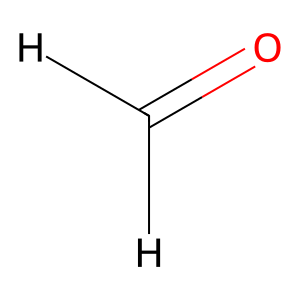

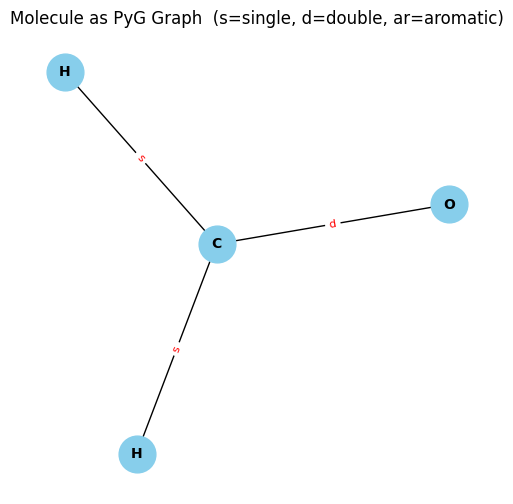

In [ ]:
def visualize_graph(mol_graph):
    """Draw the PyG molecular graph using NetworkX."""
    from torch_geometric.utils import to_networkx
    import networkx as nx

    G = to_networkx(mol_graph, to_undirected=True)
    atomic_number_map = {1:'H', 6:'C', 7:'N', 8:'O', 9:'F'}
    choices = ATOM_FEATURES["atomic_num"]
    vec_len = len(choices) + 1

    node_labels = {}
    for i, feat in enumerate(mol_graph.x):
        idx  = torch.argmax(feat[:vec_len]).item()
        anum = choices[idx] if idx < len(choices) else 0
        node_labels[i] = atomic_number_map.get(anum, f'?{anum}')

    bond_map = {0:'s', 1:'d', 2:'t', 3:'ar'}
    edge_labels = {}
    for i, (u, v) in enumerate(mol_graph.edge_index.t().tolist()):
        attr = mol_graph.edge_attr[i]
        idx  = torch.argmax(attr).item() if attr.sum() > 0 else 0
        edge_labels[(u, v)] = bond_map.get(idx, '?')

    plt.figure(figsize=(6, 6))
    pos = nx.spring_layout(G, seed=42)
    nx.draw_networkx(G, pos, labels=node_labels, node_color='skyblue',
                     node_size=700, font_size=10, font_weight='bold')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels,
                                  font_color='red', font_size=8)
    plt.title('Molecule as PyG Graph  (s=single, d=double, ar=aromatic)')
    plt.axis('off')
    plt.show()


idx = 5
print(f"Molecule {idx}  |  {TARGET_PROPERTY} = {data_csv[TARGET_PROPERTY].iloc[idx]:.5f}")
visualize_rdkit_mol_2d(molecules[idx])
visualize_graph(mol_to_graph(molecules[idx]))

---
## PART 4 — Build the Full Graph Dataset

We loop over all molecules, convert each one to a PyG graph, and save to disk
so we don't have to repeat this step (it takes a few minutes for 134k molecules).

In [ ]:
CACHE_FILE = f'mol_graphs_{TARGET_PROPERTY}.pkl'

if os.path.exists(CACHE_FILE):
    print(f"Loading cached graphs from '{CACHE_FILE}'...")
    with open(CACHE_FILE, 'rb') as f:
        mol_graphs = pickle.load(f)
    print(f"Loaded {len(mol_graphs):,} graphs.")

else:
    mol_graphs = []
    n = MAX_MOLECULES if MAX_MOLECULES else len(molecules)

    for i in tqdm(range(n), desc='Converting molecules to graphs'):
        mol = molecules[i]
        g = mol_to_graph(mol, y=float(data_csv[TARGET_PROPERTY].iloc[i]))
        if g is not None:
            mol_graphs.append(g)

    print(f"\nConverted {len(mol_graphs):,} molecules to graphs.")

    # ── Sanity check: remove any graphs with inconsistent feature dimensions ──
    n_node_feat = mol_graphs[0].num_features
    n_edge_feat = mol_graphs[0].num_edge_features
    mol_graphs = [
        g for g in mol_graphs
        if g.x.shape[1] == n_node_feat and g.edge_attr.shape[1] == n_edge_feat
    ]
    print(f"After dimension check: {len(mol_graphs):,} graphs retained.")

    # Save for reuse
    with open(CACHE_FILE, 'wb') as f:
        pickle.dump(mol_graphs, f)
    print(f"Graphs saved to '{CACHE_FILE}'")

Converting molecules to graphs:   0%|          | 0/133885 [00:00<?, ?it/s]

[16:45:24] Both bonds on one end of an atropisomer are on the same side - atoms are: 2 1
[16:45:28] ERROR: Atom line too short: ' 10  2  1  0  0  0  0' on line 561036
[16:45:28] ERROR: moving to the beginning of the next molecule
[16:45:28] ERROR: Atom line too short: ' 10  2  1  0  0  0  0' on line 561045
[16:45:28] ERROR: moving to the beginning of the next molecule
[16:45:28] ERROR: Atom line too short: ' 10  2  1  0  0  0  0' on line 561054
[16:45:28] ERROR: moving to the beginning of the next molecule
[16:45:28] ERROR: Atom line too short: ' 17  5  1  0  0  0  0' on line 561063
[16:45:28] ERROR: moving to the beginning of the next molecule
[16:45:28] ERROR: Atom line too short: ' 14  4  1  0  0  0  0' on line 561072
[16:45:28] ERROR: moving to the beginning of the next molecule
[16:45:28] ERROR: Atom line too short: ' 14  4  1  0  0  0  0' on line 561081
[16:45:28] ERROR: moving to the beginning of the next molecule
[16:45:28] ERROR: Atom line too short: ' 13  4  1  0  0  0  0' on


Converted 133,817 molecules to graphs.
After dimension check: 133,817 graphs retained.
Graphs saved to 'mol_graphs_gap.pkl'


In [ ]:
# Confirm feature sizes
NUM_NODE_FEATURES = mol_graphs[0].num_features
NUM_EDGE_FEATURES = mol_graphs[0].num_edge_features
print(f"Dataset size      : {len(mol_graphs):,} molecules")
print(f"Node feature size : {NUM_NODE_FEATURES}")
print(f"Edge feature size : {NUM_EDGE_FEATURES}")
print(f"\nExample graph: {mol_graphs[0]}")
print(f"Target value  : {mol_graphs[0].y.item():.5f}")

Dataset size      : 133,817 molecules
Node feature size : 35
Edge feature size : 18

Example graph: Data(x=[5, 35], edge_index=[2, 8], edge_attr=[8, 18], y=[1])
Target value  : 0.50480


---
## PART 5 — Train / Validation / Test Split and DataLoaders

Split: **80% train / 10% validation / 10% test**  
We shuffle first so the split is random, not biased by molecule index order.




In [ ]:
random.shuffle(mol_graphs)   # shuffle in-place

n         = len(mol_graphs)
train_end = int(n * 0.80)
val_end   = int(n * 0.90)

train_data = mol_graphs[:train_end]
val_data   = mol_graphs[train_end:val_end]
test_data  = mol_graphs[val_end:]

print(f"Train : {len(train_data):,}  ({len(train_data)/n*100:.1f}%)")
print(f"Val   : {len(val_data):,}   ({len(val_data)/n*100:.1f}%)")
print(f"Test  : {len(test_data):,}   ({len(test_data)/n*100:.1f}%)")

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False)

print(f"\nBatches per epoch : {len(train_loader)}")

Train : 107,053  (80.0%)
Val   : 13,382   (10.0%)
Test  : 13,382   (10.0%)

Batches per epoch : 837


---
## PART 6 — GNN Model Architectures

### GCN — Graph Convolutional Network (Kipf & Welling, 2017)



### GIN — Graph Isomorphism Network (Xu et al., 2019)





In [ ]:
class GCN(torch.nn.Module):
    """3-layer Graph Convolutional Network for molecular property regression."""

    def __init__(self, dim_input, dim_hidden):
        super().__init__()
        self.conv1 = GCNConv(dim_input,  dim_hidden)
        self.conv2 = GCNConv(dim_hidden, dim_hidden)
        self.conv3 = GCNConv(dim_hidden, dim_hidden)
        self.lin   = Linear(dim_hidden, 1)

    def forward(self, data):
        x, e = data.x.float(), data.edge_index

        # Message-passing: each atom collects info from its bonded neighbours
        x = self.conv1(x, e).relu()   # layer 1
        x = self.conv2(x, e).relu()   # layer 2
        x = self.conv3(x, e)          # layer 3  (no activation before pooling)

        # Readout: average all atom embeddings → one vector per molecule
        x = global_mean_pool(x, data.batch)

        x = Fun.dropout(x, p=0.5, training=self.training)  # regularisation
        return self.lin(x)  # scalar prediction


class GIN(torch.nn.Module):
    """3-layer Graph Isomorphism Network for molecular property regression."""

    def __init__(self, dim_input, dim_hidden):
        super().__init__()

        def mlp(in_d, out_d):
            """2-layer MLP with BatchNorm used inside each GINConv layer."""
            return Sequential(
                Linear(in_d, out_d), BatchNorm1d(out_d), ReLU(),
                Linear(out_d, out_d), ReLU()
            )

        self.conv1 = GINConv(mlp(dim_input,  dim_hidden))
        self.conv2 = GINConv(mlp(dim_hidden, dim_hidden))
        self.conv3 = GINConv(mlp(dim_hidden, dim_hidden))
        self.lin1  = Linear(dim_hidden, dim_hidden)
        self.lin2  = Linear(dim_hidden, 1)

    def forward(self, data):
        x, ei, batch = data.x.float(), data.edge_index, data.batch

        h = self.conv1(x, ei).relu()
        h = self.conv2(h, ei).relu()
        h = self.conv3(h, ei)

        # Sum pooling works well for extensive QM9 properties (energy etc.)
        h = global_add_pool(h, batch)

        h = self.lin1(h).relu()
        h = Fun.dropout(h, p=0.5, training=self.training)
        return self.lin2(h)


# Preview model summaries
m = GIN(NUM_NODE_FEATURES, DIM_HIDDEN)
print(m)
print(f"\nGIN parameters : {sum(p.numel() for p in m.parameters()):,}")

GIN(
  (conv1): GINConv(nn=Sequential(
    (0): Linear(in_features=35, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=128, bias=True)
    (4): ReLU()
  ))
  (conv2): GINConv(nn=Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=128, bias=True)
    (4): ReLU()
  ))
  (conv3): GINConv(nn=Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=128, bias=True)
    (4): ReLU()
  ))
  (lin1): Linear(in_features=128, out_features=128, bias=True)
  (lin2): Linear(in_features=128, out_features=1, bias=True)
)

GIN parameters

---
## PART 7 — Training Utilities


- **`train_one_epoch`** — loops through training batches, computes MSE loss, backpropagates
- **`validate`** — evaluates on val/test set without updating weights
- **`train_epochs`** — full training loop with best-model checkpointing
- **`plot_loss`** — training/validation loss curve (log scale)
- **`plot_parity`** — predicted vs actual scatter + residuals + metrics

In [ ]:
def train_one_epoch(loader, model, loss_fn, optimizer):
    """One forward+backward pass over the training set. Returns average MSE."""
    model.train()
    total = 0.0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        pred   = model(batch)
        target = batch.y.reshape(-1, 1)
        loss   = loss_fn(pred, target)
        loss.backward()
        optimizer.step()
        total += loss.item() / len(loader)
    return total


@torch.no_grad()
def validate(loader, model, loss_fn):
    """Evaluate MSE on a DataLoader without gradient updates."""
    model.eval()
    total = 0.0
    for batch in loader:
        batch  = batch.to(device)
        pred   = model(batch)
        target = batch.y.reshape(-1, 1)
        total += loss_fn(pred, target).item() / len(loader)
    return total


def train_epochs(model, train_loader, val_loader, epochs, lr, save_path):
    """
    Full training loop.
    - Uses Adam optimiser and MSE loss
    - Saves the checkpoint with the lowest validation loss
    - Prints progress every 10 epochs
    Returns train_losses and val_losses (numpy arrays of length = epochs)
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn   = torch.nn.MSELoss()
    best_val  = math.inf

    train_losses = np.empty(epochs)
    val_losses   = np.empty(epochs)

    for epoch in range(epochs):
        t = train_one_epoch(train_loader, model, loss_fn, optimizer)
        v = validate(val_loader,          model, loss_fn)

        train_losses[epoch] = t
        val_losses[epoch]   = v

        if v < best_val:
            best_val = v
            torch.save(model.state_dict(), save_path)

        if epoch % 10 == 0 or epoch == epochs - 1:
            print(f"Epoch {epoch:4d} | train MSE {t:.6f} | val MSE {v:.6f}"
                  + (" ← best" if v == best_val else ""))

    print(f"\n★ Best validation MSE: {best_val:.6f}  — model saved to '{save_path}'")
    return train_losses, val_losses


# ── Plotting helpers ──────────────────────────────────────────────────────────

def plot_loss(train_losses, val_losses, title=''):
    """Plot train/val MSE loss curves on a log scale."""
    plt.figure(figsize=(8, 4))
    plt.plot(train_losses, label='Train')
    plt.plot(val_losses,   label='Validation')
    plt.yscale('log')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss (log scale)')
    plt.title(f'Training curves{" — " + title if title else ""}')
    plt.legend()
    plt.tight_layout()
    plt.show()


@torch.no_grad()
def collect_predictions(loader, model):
    """Return (predicted, true) numpy arrays for all samples in loader."""
    model.eval()
    preds, trues = [], []
    for batch in loader:
        batch = batch.to(device)
        preds.append(model(batch).cpu().numpy()[:, 0])
        trues.append(batch.y.cpu().numpy())
    return np.concatenate(preds), np.concatenate(trues)


def plot_parity(model, train_loader, val_loader, test_loader, title=''):
    """
    Three plots:
    1. Parity plot (predicted vs actual) with diagonal reference line
    2. Residual plot (actual − predicted vs predicted)
    3. Residual distribution (KDE)
    Also prints RMSE, MAE, R² for each split.
    """
    tr_p, tr_t = collect_predictions(train_loader, model)
    va_p, va_t = collect_predictions(val_loader,   model)
    te_p, te_t = collect_predictions(test_loader,  model)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # 1. Parity plot
    ax = axes[0]
    ax.scatter(tr_p, tr_t, s=1, alpha=0.2, label='Train')
    ax.scatter(va_p, va_t, s=3, alpha=0.4, label='Validation')
    ax.scatter(te_p, te_t, s=3, alpha=0.5, label='Test')
    lo = min(tr_t.min(), te_t.min())
    hi = max(tr_t.max(), te_t.max())
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1.5, label='Ideal')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'Parity — {title}')
    ax.legend(markerscale=5)

    # 2. Residual plot
    ax = axes[1]
    ax.scatter(tr_p, tr_t - tr_p, s=1, alpha=0.2, label='Train')
    ax.scatter(va_p, va_t - va_p, s=3, alpha=0.4, label='Validation')
    ax.scatter(te_p, te_t - te_p, s=3, alpha=0.5, label='Test')
    ax.axhline(0, color='red', linewidth=1.5, linestyle='--')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Residual (actual − predicted)')
    ax.set_title('Residuals')
    ax.legend(markerscale=5)

    # 3. Residual distribution
    ax = axes[2]
    sns.kdeplot(tr_t - tr_p, ax=ax, label='Train',      fill=True, alpha=0.3)
    sns.kdeplot(va_t - va_p, ax=ax, label='Validation', fill=True, alpha=0.3)
    sns.kdeplot(te_t - te_p, ax=ax, label='Test',       fill=True, alpha=0.3)
    ax.axvline(0, color='red', linewidth=1.5, linestyle='--')
    ax.set_xlabel('Residual')
    ax.set_title('Residual Distribution')
    ax.legend()

    plt.suptitle(title, fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

    # Print metrics
    print(f"\n{'Split':<10} {'RMSE':>10} {'MAE':>10} {'R²':>8}")
    print("-" * 42)
    for name, p, t in [('Train', tr_p, tr_t), ('Validation', va_p, va_t), ('Test', te_p, te_t)]:
        rmse = np.sqrt(np.mean((p - t) ** 2))
        mae  = mean_absolute_error(t, p)
        r2   = r2_score(t, p)
        print(f"{name:<10} {rmse:>10.5f} {mae:>10.5f} {r2:>8.4f}")


print("Training utilities defined.")

Training utilities defined.


---
## PART 8 — Train the GCN Model

In [ ]:
model_gcn = GCN(dim_input=NUM_NODE_FEATURES, dim_hidden=DIM_HIDDEN).to(device)
print(model_gcn)
print(f"Total parameters: {sum(p.numel() for p in model_gcn.parameters()):,}")

GCN(
  (conv1): GCNConv(35, 128)
  (conv2): GCNConv(128, 128)
  (conv3): GCNConv(128, 128)
  (lin): Linear(in_features=128, out_features=1, bias=True)
)
Total parameters: 37,761


In [ ]:
gcn_train_loss, gcn_val_loss = train_epochs(
    model        = model_gcn,
    train_loader = train_loader,
    val_loader   = val_loader,
    epochs       = EPOCHS,
    lr           = LEARNING_RATE,
    save_path    = 'best_model_gcn.pt'
)

Epoch    0 | train MSE 0.001648 | val MSE 0.000575 ← best
Epoch   10 | train MSE 0.000307 | val MSE 0.000310
Epoch   20 | train MSE 0.000275 | val MSE 0.000273
Epoch   30 | train MSE 0.000252 | val MSE 0.000250
Epoch   40 | train MSE 0.000240 | val MSE 0.000228 ← best
Epoch   50 | train MSE 0.000229 | val MSE 0.000231
Epoch   60 | train MSE 0.000222 | val MSE 0.000221
Epoch   70 | train MSE 0.000217 | val MSE 0.000272
Epoch   80 | train MSE 0.000212 | val MSE 0.000206
Epoch   90 | train MSE 0.000208 | val MSE 0.000213
Epoch  100 | train MSE 0.000206 | val MSE 0.000210
Epoch  110 | train MSE 0.000204 | val MSE 0.000198
Epoch  120 | train MSE 0.000201 | val MSE 0.000207
Epoch  130 | train MSE 0.000198 | val MSE 0.000196
Epoch  140 | train MSE 0.000197 | val MSE 0.000207
Epoch  150 | train MSE 0.000196 | val MSE 0.000199
Epoch  160 | train MSE 0.000194 | val MSE 0.000198
Epoch  170 | train MSE 0.000192 | val MSE 0.000191
Epoch  180 | train MSE 0.000191 | val MSE 0.000190
Epoch  190 | trai

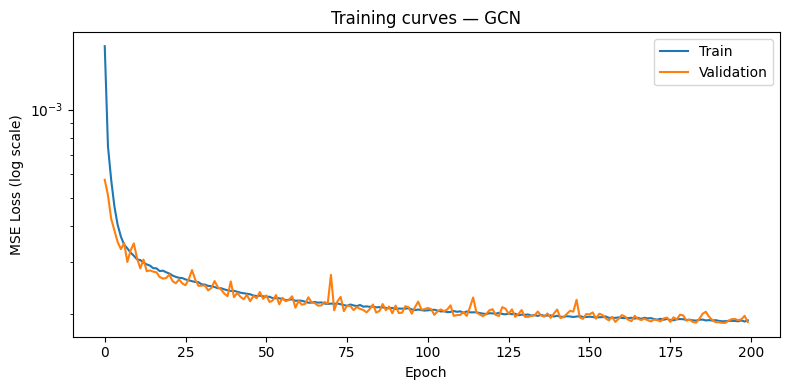

In [ ]:
plot_loss(gcn_train_loss, gcn_val_loss, title='GCN')

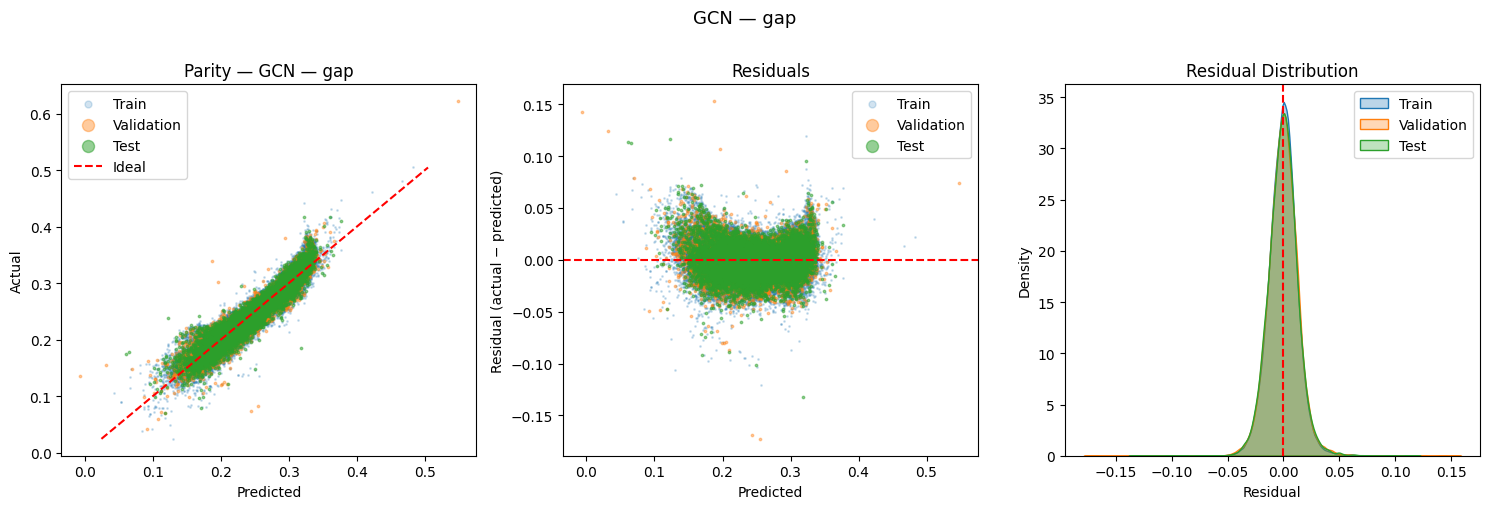


Split            RMSE        MAE       R²
------------------------------------------
Train         0.01290    0.00984   0.9263
Validation    0.01365    0.01017   0.9183
Test          0.01349    0.01015   0.9191


In [ ]:
# Load the best checkpoint (lowest val loss) before evaluating
model_gcn.load_state_dict(torch.load('best_model_gcn.pt', map_location=device))
plot_parity(model_gcn, train_loader, val_loader, test_loader, title=f'GCN — {TARGET_PROPERTY}')

---
## PART 9 — Train the GIN Model

In [ ]:
model_gin = GIN(dim_input=NUM_NODE_FEATURES, dim_hidden=DIM_HIDDEN).to(device)
print(model_gin)
print(f"Total parameters: {sum(p.numel() for p in model_gin.parameters()):,}")

GIN(
  (conv1): GINConv(nn=Sequential(
    (0): Linear(in_features=35, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=128, bias=True)
    (4): ReLU()
  ))
  (conv2): GINConv(nn=Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=128, bias=True)
    (4): ReLU()
  ))
  (conv3): GINConv(nn=Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=128, bias=True)
    (4): ReLU()
  ))
  (lin1): Linear(in_features=128, out_features=128, bias=True)
  (lin2): Linear(in_features=128, out_features=1, bias=True)
)
Total parameter

In [ ]:
gin_train_loss, gin_val_loss = train_epochs(
    model        = model_gin,
    train_loader = train_loader,
    val_loader   = val_loader,
    epochs       = EPOCHS,
    lr           = LEARNING_RATE,
    save_path    = 'best_model_gin.pt'
)

Epoch    0 | train MSE 0.014324 | val MSE 0.000708 ← best
Epoch   10 | train MSE 0.000373 | val MSE 0.000208
Epoch   20 | train MSE 0.000242 | val MSE 0.000135 ← best
Epoch   30 | train MSE 0.000184 | val MSE 0.000123
Epoch   40 | train MSE 0.000154 | val MSE 0.000097
Epoch   50 | train MSE 0.000148 | val MSE 0.000091 ← best
Epoch   60 | train MSE 0.000141 | val MSE 0.000091
Epoch   70 | train MSE 0.000131 | val MSE 0.000106
Epoch   80 | train MSE 0.000127 | val MSE 0.000081 ← best
Epoch   90 | train MSE 0.000120 | val MSE 0.000088
Epoch  100 | train MSE 0.000119 | val MSE 0.000084
Epoch  110 | train MSE 0.000117 | val MSE 0.000079
Epoch  120 | train MSE 0.000115 | val MSE 0.000081
Epoch  130 | train MSE 0.000114 | val MSE 0.000077
Epoch  140 | train MSE 0.000112 | val MSE 0.000075
Epoch  150 | train MSE 0.000111 | val MSE 0.000084
Epoch  160 | train MSE 0.000109 | val MSE 0.000077
Epoch  170 | train MSE 0.000108 | val MSE 0.000074
Epoch  180 | train MSE 0.000107 | val MSE 0.000080
Epo

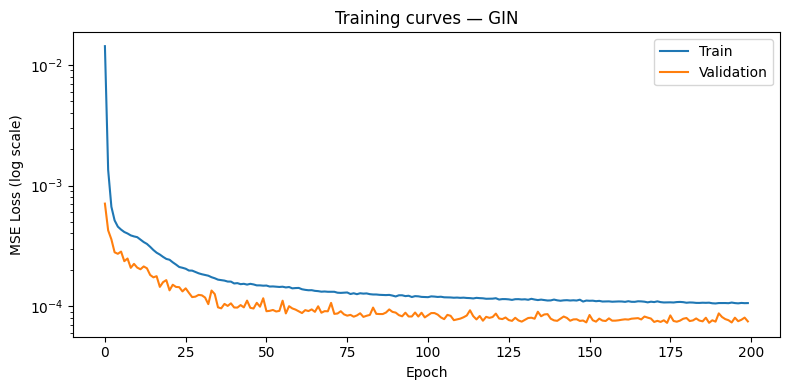

In [ ]:
plot_loss(gin_train_loss, gin_val_loss, title='GIN')

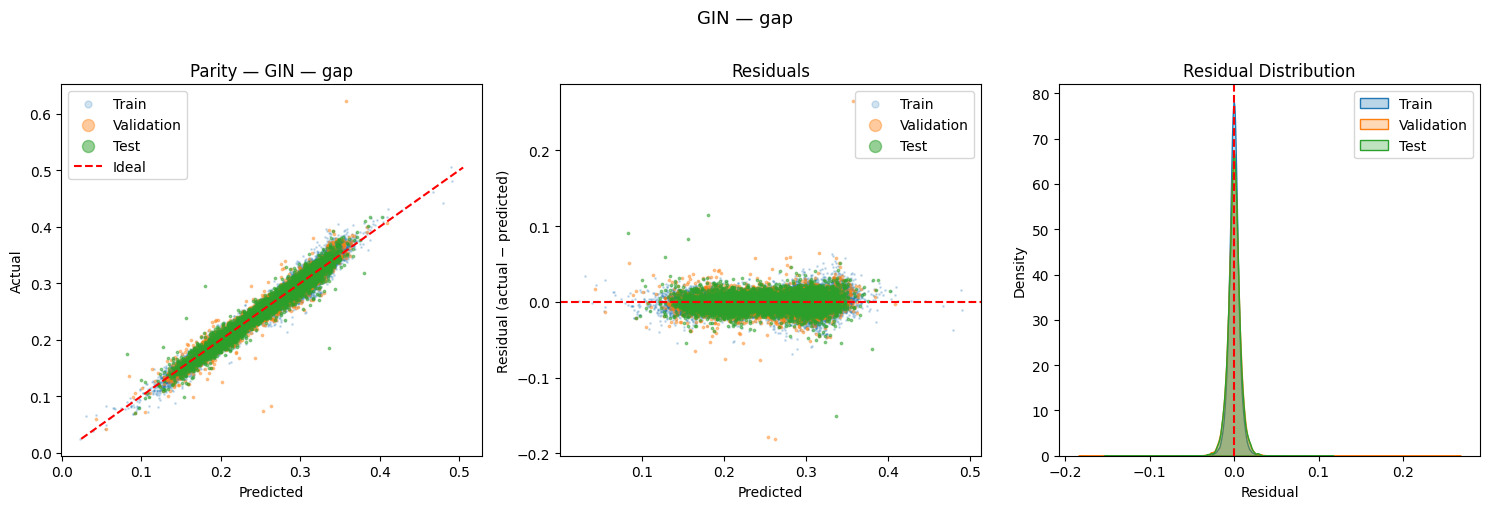


Split            RMSE        MAE       R²
------------------------------------------
Train         0.00643    0.00470   0.9817
Validation    0.00852    0.00568   0.9682
Test          0.00788    0.00556   0.9724


In [ ]:
model_gin.load_state_dict(torch.load('best_model_gin.pt', map_location=device))
plot_parity(model_gin, train_loader, val_loader, test_loader, title=f'GIN — {TARGET_PROPERTY}')

---
## PART 10 — GCN vs GIN Comparison

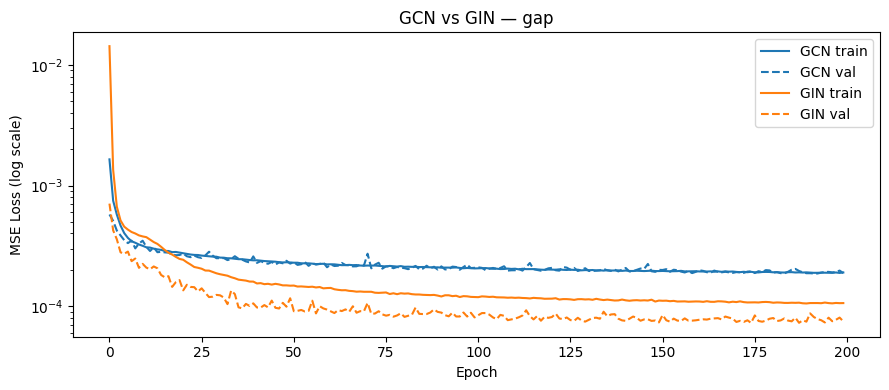

Best GCN val MSE : 0.000186
Best GIN val MSE : 0.000073


In [ ]:
plt.figure(figsize=(9, 4))
plt.plot(gcn_train_loss, color='C0', linestyle='-',  label='GCN train')
plt.plot(gcn_val_loss,   color='C0', linestyle='--', label='GCN val')
plt.plot(gin_train_loss, color='C1', linestyle='-',  label='GIN train')
plt.plot(gin_val_loss,   color='C1', linestyle='--', label='GIN val')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss (log scale)')
plt.title(f'GCN vs GIN — {TARGET_PROPERTY}')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Best GCN val MSE : {gcn_val_loss.min():.6f}")
print(f"Best GIN val MSE : {gin_val_loss.min():.6f}")

---
## PART 11 — Prediction from a SMILES String

### Applicability Domain Checks

Before predicting, we verify the molecule is within the model's training domain:

| Check | Rule |
|-------|------|
| Valid SMILES | RDKit can parse it |
| Atom types | Only H, C, N, O, F (HCONF) |
| Size | ≤ 9 heavy atoms |
| Connectivity | Single connected molecule |

Predictions outside the domain are flagged with a ⚠️ warning.

In [ ]:
ALLOWED_ATOMS   = {1, 6, 7, 8, 9}   # H, C, N, O, F
MAX_HEAVY_ATOMS = 9


def check_applicability(smiles: str):
    """
    Check whether a SMILES string is within the QM9 model's applicability domain.

    Returns:
        mol      : RDKit Mol with explicit Hs added, or None if invalid
        ok       : True if all checks pass
        messages : list of status strings (✅ / ⚠️ / ❌)
    """
    messages = []
    ok = True

    # 1. Parse SMILES
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        messages.append("❌  Invalid SMILES — RDKit cannot parse this string.")
        return None, False, messages
    messages.append("✅  Valid SMILES.")

    # Add explicit Hs to match QM9 representation
    mol = Chem.AddHs(mol)

    # 2. Atom types
    atom_nums = {a.GetAtomicNum() for a in mol.GetAtoms()}
    forbidden = atom_nums - ALLOWED_ATOMS
    if forbidden:
        syms = [Chem.Atom(n).GetSymbol() for n in forbidden]
        messages.append(f"❌  Contains atoms outside QM9 scope: {syms}. "
                        f"Model is only valid for H, C, N, O, F molecules.")
        ok = False
    else:
        messages.append("✅  Only HCONF atoms — within QM9 scope.")

    # 3. Heavy-atom count
    n_heavy = sum(1 for a in mol.GetAtoms() if a.GetAtomicNum() != 1)
    if n_heavy > MAX_HEAVY_ATOMS:
        messages.append(f"⚠️   {n_heavy} heavy atoms — QM9 contains ≤{MAX_HEAVY_ATOMS}. "
                        f"Prediction may be unreliable (extrapolation beyond training domain).")
        ok = False
    else:
        messages.append(f"✅  {n_heavy} heavy atom(s) — within QM9 size range (≤{MAX_HEAVY_ATOMS}).")

    # 4. Single connected fragment
    frags = Chem.GetMolFrags(mol)
    if len(frags) > 1:
        messages.append(f"⚠️   {len(frags)} disconnected fragments — QM9 contains only single molecules.")
        ok = False
    else:
        messages.append("✅  Single connected molecule.")

    return mol, ok, messages


@torch.no_grad()
def predict_from_smiles(smiles: str, model=None, show_molecule: bool = True):
    """
    Predict the target QM9 property for a given SMILES string.

    Steps:
      1. Applicability domain check
      2. mol_to_graph conversion
      3. GNN forward pass
      4. Return predicted value

    Parameters:
        smiles        : SMILES string
        model         : trained GNN model (default: model_gin)
        show_molecule : whether to draw the 2D structure
    """
    if model is None:
        model = model_gin   # use GIN by default

    print(f"SMILES : {smiles}")
    print("-" * 55)

    # Step 1 — applicability checks
    mol, ok, messages = check_applicability(smiles)
    for msg in messages:
        print(msg)

    if mol is None:
        print("\n❌  Cannot proceed — invalid SMILES.")
        return None

    if not ok:
        print("\n⚠️  WARNING: molecule is outside the applicability domain.")
        print(   "   Prediction shown below but should be treated with caution.")

    # Step 2 — draw 2D structure
    if show_molecule:
        mol_2d = Chem.RemoveHs(Chem.RWMol(mol))
        rdDepictor.Compute2DCoords(mol_2d)
        display(MolToImage(mol_2d, size=(300, 300)))

    # Step 3 — graph conversion + prediction
    graph = mol_to_graph(mol)
    if graph is None:
        print("❌  Graph conversion failed.")
        return None

    loader = DataLoader([graph], batch_size=1)
    batch  = next(iter(loader)).to(device)

    model.eval()
    pred = model(batch).item()

    print(f"\n★  Predicted {TARGET_PROPERTY} : {pred:.6f}")
    return pred


print("Prediction functions defined.")

Prediction functions defined.


### Single molecule prediction

**Change `smiles_to_predict` to any SMILES you want to test.**

SMILES : CCO
-------------------------------------------------------
✅  Valid SMILES.
✅  Only HCONF atoms — within QM9 scope.
✅  3 heavy atom(s) — within QM9 size range (≤9).
✅  Single connected molecule.


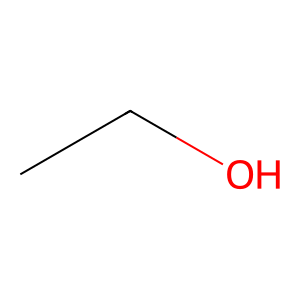


★  Predicted gap : 0.324968


0.32496827840805054

In [ ]:
# ── Enter your SMILES here ──────────────────────────────────────────────────
smiles_to_predict = 'CCO'   # ethanol
# ───────────────────────────────────────────────────────────────────────────

predict_from_smiles(smiles_to_predict, model=model_gin)

SMILES : c1ccc(cc1)Cl
-------------------------------------------------------
✅  Valid SMILES.
❌  Contains atoms outside QM9 scope: ['Cl']. Model is only valid for H, C, N, O, F molecules.
✅  7 heavy atom(s) — within QM9 size range (≤9).
✅  Single connected molecule.

⚠️  WARNING: molecule is outside the applicability domain.
   Prediction shown below but should be treated with caution.


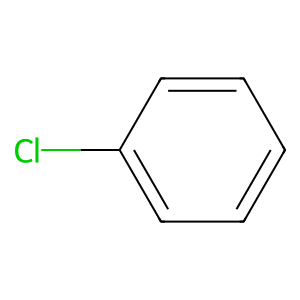


★  Predicted gap : 0.196574


0.1965739130973816

In [ ]:
# Test with a molecule OUTSIDE the domain (Cl not in HCONF)
predict_from_smiles('c1ccc(cc1)Cl', model=model_gin)   # chlorobenzene

### Batch predictions across several molecules

In [ ]:
test_molecules = [
    ('Methane',        'C'),
    ('Ethanol',        'CCO'),
    ('Benzene',        'c1ccccc1'),
    ('Acetamide',      'CC(=O)N'),
    ('Formaldehyde',   'C=O'),
    ('Fluoromethane',  'CF'),
    ('Methylamine',    'CN'),
    ('Acetic acid',    'CC(=O)O'),
]

print(f"{'Molecule':<18} {'SMILES':<22} {TARGET_PROPERTY:>12}  {'In domain?'}")
print("-" * 65)

for name, smi in test_molecules:
    mol, ok, _ = check_applicability(smi)
    if mol is not None:
        g = mol_to_graph(mol)
        loader = DataLoader([g], batch_size=1)
        batch  = next(iter(loader)).to(device)
        model_gin.eval()
        with torch.no_grad():
            pred = model_gin(batch).item()
        domain = '✅' if ok else '⚠️ outside'
        print(f"{name:<18} {smi:<22} {pred:>12.5f}  {domain}")
    else:
        print(f"{name:<18} {smi:<22} {'INVALID':>12}")

Molecule           SMILES                          gap  In domain?
-----------------------------------------------------------------
Methane            C                           0.44415  ✅
Ethanol            CCO                         0.32497  ✅
Benzene            c1ccccc1                    0.19098  ✅
Acetamide          CC(=O)N                     0.29045  ✅
Formaldehyde       C=O                         0.23157  ✅
Fluoromethane      CF                          0.43168  ✅
Methylamine        CN                          0.32597  ✅
Acetic acid        CC(=O)O                     0.26313  ✅


---
## PART 12 — Summary

- Processed the QM9 dataset (~134k molecules) using RDKit and PyTorch Geometric
- Used the **HOMO–LUMO gap (gap)** molecular property as a target feature
- Converted molecules into graph representations with atom and bond features
- Split data into 80/10/10 train, validation, and test sets
Implemented **GCN and GIN models** for molecular property prediction
- Trained models using Adam optimizer and MSE loss for 200 epochs
- Used batch size = 128 and learning rate = 5×10
−4
- Evaluated performance using RMSE, MAE, and R2
 metrics
- Created a SMILES-based prediction workflow with applicability checks


